In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
!pip install seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: C:\Users\adhamz\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [3]:
races = pd.read_csv("Nemo.csv")
forcedecks = pd.read_csv("Forcedeck.csv")

In [4]:
#Get rid of rows that will mess with signal (non-real races)
races = races[  
~races["CompetitionName"].isin(["Training", "Certification 2026", "CERTIFICATION 2025", "CERTIFICATION 2023", "CERTIFICATION 2022"])  
]

In [5]:
fd_cmj = forcedecks[forcedecks["Test Type"] == "CMJ"].copy()

In [6]:
RACE_NAME_COL = "AthleteName"    # name column in races dataset
CMJ_NAME_COL  = "About"    # name column in cmj dataset (even if different)
RACE_DATE     = "Date"
CMJ_DATE      = "Date"
EVENT_COL     = "RaceEventName"
TIME_COL      = "RaceTime"
CMJ_COL       = "Jump Height (Flight Time) [cm]"
TOLERANCE     = pd.Timedelta("60 days")

In [7]:
# Normalise names — lowercase
races["athlete_key"] = races[RACE_NAME_COL].str.lower().str.strip()
fd_cmj["athlete_key"]   = fd_cmj[CMJ_NAME_COL].str.lower().str.strip()

C:\Users\adhamz\AppData\Local\Temp\ipykernel_26024\3360544719.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  races["athlete_key"] = races[RACE_NAME_COL].str.lower().str.strip()


In [8]:
races[RACE_DATE] = pd.to_datetime(races[RACE_DATE], dayfirst = True)
fd_cmj[CMJ_DATE]    = pd.to_datetime(fd_cmj[CMJ_DATE], dayfirst = True)

In [9]:
# Filter to 50m freestyle only
races_50free = races[races[EVENT_COL] == "50 m Freestyle"].copy()

# Filter to CMJ data window
races_50free = races_50free[races_50free[RACE_DATE] >= "2023-10-01"].copy()

In [10]:
print(f"50m freestyle races in window: {len(races_50free)}")
print(f"CMJ tests available:           {len(fd_cmj)}")

50m freestyle races in window: 43
CMJ tests available:           1722


In [11]:
# Sort by date (required for merge_asof)
races_50free = races_50free.sort_values(RACE_DATE)
fd_cmj = fd_cmj.sort_values(CMJ_DATE)

# Merge each race to the nearest CMJ test for that athlete
df = pd.merge_asof(
    races_50free,
    fd_cmj,
    left_on=RACE_DATE,
    right_on=CMJ_DATE,
    by="athlete_key",
    direction="nearest",
    tolerance=TOLERANCE,
    suffixes=("_race", "_cmj")
)

# Drop races where no CMJ fell within the tolerance window
df = df.dropna(subset=[CMJ_COL])

print(f"Valid race–CMJ pairings: {len(df)}")
df.head()

Valid race–CMJ pairings: 7


,RaceId,PoolLength,PhaseNumber,Date,Lane,RelayLeg,FinishingPosition,RaceEventId,RaceEventDistance,RaceEventIsMixed,...,Month,Month with Number,Year,Session Date,Date Reverse,CMJ JH Filter,CMJ PP Filter,Week Year,event-uuid,group-uuid
5,427cd132-1448-4b5d-96a4-b328a33b385f,50,5.0,2024-03-08,5.0,NaN,1.0,10,50,False,...,Mar,03-Mar,2024.0,04/03/2024,04/03/2024,CMJ JH,CMJ PP,2024-Wk10,8589c2ff-8fcd-4369-a157-9ecf51418234,2b8c156f-d9d1-4960-9e72-330686cb2b16
6,72fd6ee8-f393-41e4-8f68-df1bac4843b4,50,NaN,2024-03-08,3.0,NaN,2.0,10,50,False,...,Mar,03-Mar,2024.0,04/03/2024,04/03/2024,CMJ JH,CMJ PP,2024-Wk10,8589c2ff-8fcd-4369-a157-9ecf51418234,2b8c156f-d9d1-4960-9e72-330686cb2b16
9,39d0e734-a753-4c99-b095-74271eef0106,50,5.0,2024-03-09,3.0,NaN,3.0,10,50,False,...,Mar,03-Mar,2024.0,12/03/2024,12/03/2024,CMJ JH,CMJ PP,2024-Wk11,db6c6a91-51d4-47c2-9151-8c24cbb57e42,9b51cd9f-ba8b-4ce7-b5e9-5d7fecc65451
10,bad06094-6477-4c5c-9077-47ab06cc4f01,50,NaN,2024-03-09,6.0,NaN,4.0,10,50,False,...,Mar,03-Mar,2024.0,12/03/2024,12/03/2024,CMJ JH,CMJ PP,2024-Wk11,0e9a213a-7366-4932-a3ed-fd084c06ed5a,779b25fd-10df-479f-962c-861c69ee5322
12,19f09be6-1732-4a37-91f6-77fdcc787559,50,4.0,2024-03-09,4.0,NaN,1.0,10,50,False,...,Mar,03-Mar,2024.0,12/03/2024,12/03/2024,CMJ JH,CMJ PP,2024-Wk11,0e9a213a-7366-4932-a3ed-fd084c06ed5a,779b25fd-10df-479f-962c-861c69ee5322


In [12]:
unmatched = set(races_50free["athlete_key"]) - set(fd_cmj["athlete_key"])
print("Names in races but not CMJ:", unmatched)

Names in races but not CMJ: {'evan jones', 'abby kane', 'jamie robertson', 'evelyn davis', 'lucy hope'}


In [13]:
print(f"Total rows: {len(df)}")
print(f"Unique athletes: {df['athlete_key'].nunique()}")
print(df.groupby("athlete_key").size().rename("race_count"))

Total rows: 7
Unique athletes: 4
athlete_key
duncan scott      2
freya anderson    2
jack mcmillan     1
katie shanahan    2
Name: race_count, dtype: int64


In [15]:
# All athletes in the filtered races dataset
race_athletes = set(races_50free["athlete_key"])

# All athletes in CMJ
cmj_athletes = set(fd_cmj["athlete_key"])

# Who is in races but not matching in CMJ
print("In races but not in CMJ:")
print(race_athletes - cmj_athletes)

In races but not in CMJ:
{'evan jones', 'abby kane', 'jamie robertson', 'evelyn davis', 'lucy hope'}


In [16]:
# Select the two variables needed for regression
X_col = "Jump Height (Flight Time) [cm]"   # predictor
y_col = "RaceTime"          # output variable

df_clean = df[[X_col, y_col]].dropna()

print(f"Rows after dropping nulls: {len(df_clean)}")
print(df_clean.describe())

Rows after dropping nulls: 7
       Jump Height (Flight Time) [cm]   RaceTime
count                        7.000000   7.000000
mean                        39.756286  24.618571
std                          9.919602   1.801929
min                         29.915000  22.410000
25%                         31.915500  22.925000
50%                         33.916000  25.490000
75%                         50.054000  26.025000
max                         50.524000  26.530000


In [18]:
from sklearn.model_selection import LeaveOneOut, cross_val_predict

X = df_clean[[CMJ_COL]].values
y = df_clean[TIME_COL].values

model = LinearRegression()
loo   = LeaveOneOut()

# Generate predictions where each point was the held-out test case
y_pred_loo = cross_val_predict(model, X, y, cv=loo)

# Fit on all data for the final model coefficients and plot
model.fit(X, y)

r2   = r2_score(y, y_pred_loo)
rmse = np.sqrt(mean_squared_error(y, y_pred_loo))

print(f"LOOCV R²   : {r2:.3f}")
print(f"LOOCV RMSE : {rmse:.3f} seconds")
print(f"Intercept  : {model.intercept_:.4f}")
print(f"Slope      : {model.coef_[0]:.4f}")
print(f"\nFor each 1 cm increase in CMJ, 50m time changes by {model.coef_[0]:.4f} seconds")

LOOCV R²   : 0.731
LOOCV RMSE : 0.865 seconds
Intercept  : 31.2814
Slope      : -0.1676

For each 1 cm increase in CMJ, 50m time changes by -0.1676 seconds


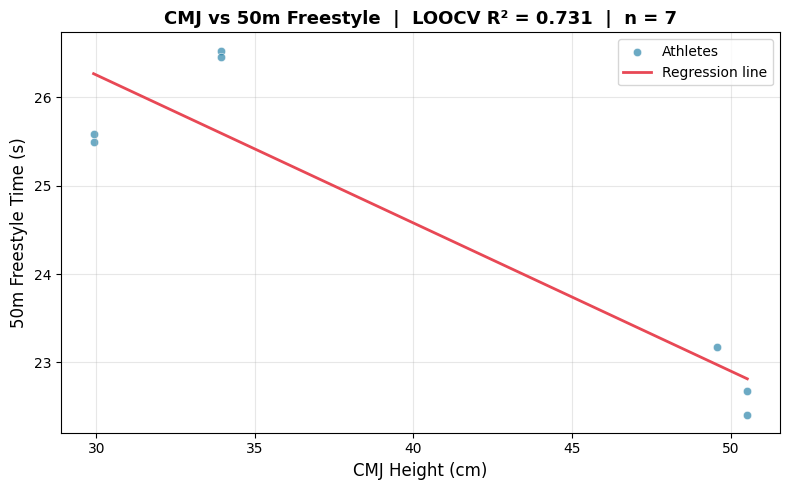

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    df_clean[CMJ_COL], df_clean[TIME_COL],
    alpha=0.7, edgecolors="white", linewidths=0.5,
    color="#2E86AB", label="Athletes"
)

x_line = np.linspace(df_clean[CMJ_COL].min(), df_clean[CMJ_COL].max(), 200).reshape(-1, 1)
ax.plot(x_line, model.predict(x_line), color="#E84855", linewidth=2, label="Regression line")

ax.set_xlabel("CMJ Height (cm)", fontsize=12)
ax.set_ylabel("50m Freestyle Time (s)", fontsize=12)
ax.set_title(f"CMJ vs 50m Freestyle  |  LOOCV R² = {r2:.3f}  |  n = {len(df_clean)}", fontsize=13, fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("cmj_vs_50m_regression.png", dpi=150)
plt.show()